# STACS Scaling Study — Runtime vs. Network Size

This notebook grows the same excitatory/inhibitory/input reservoir from the ICONS 2025 tutorial
across several grid sizes, and records how build time, simulate time, memory, and network size
actually scale on a single local machine.

**Important framing before you run this:** the paper's weak-scaling study grows the network *and*
adds more compute nodes at the same rate, so the per-process workload stays constant — that's why
their curves look nearly flat. Here, `num_pe` (the number of local processes) is held **fixed**
while the network grows, so you should *expect* runtimes to grow faster than linear, not stay flat.
That's not a bug — it's the thing this notebook is actually measuring: how STACS behaves when problem
size outpaces available compute, which is the realistic situation on a laptop.

Populations scale with **area** so that neuron *density* (and therefore expected synapses per neuron)
stays constant as the grid grows — same spirit as the paper's weak scaling, just without the added
compute to match.

## Setup

In [1]:
import os
import re
import sys
import time
import shutil
import subprocess

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

STACSDIR = '..' # path to the STACS repo root (containing charmrun/stacs), relative to this notebook
BASEDIR = './scaling' # where this notebook will write all experiment folders
os.makedirs(BASEDIR, exist_ok=True)


## Config-generation helpers

Identical to the ICONS 2025 tutorial — copied verbatim so this notebook is self-contained.

In [2]:
# Model registry
model_registry = dict()
model_registry['izhi_neuron'] = 'izhi_neuron_clamp'
model_registry['izhi_syn_stdp'] = 'izhi_syn_stdp'
model_registry['izhi_syn'] = 'simple_synapse'
model_registry['input_syn'] = 'spike_clamp'
model_registry['spike_input'] = 'spike_input'

def substrate_model(type, model_name, model_type, params=None, states=None, ports=None):
    model_dict = dict()
    model_dict['type'] = type
    model_dict['modname'] = model_name
    model_dict['modtype'] = model_registry[model_type]
    if params is not None:
        model_dict['param'] = list()
        for k, v in params.items():
            model_dict['param'].append({'name': k, 'value': v})
    if states is not None:
        model_dict['state'] = list()
        for k, v in states.items():
            if isinstance(v, dict):
                model_dict['state'].append({'name': k, **v})
            else:
                model_dict['state'].append({'name': k, 'init': 'constant', 'value': v})
            if k == 'delay':
                model_dict['state'][-1]['rep'] = 'tick'
    if ports is not None:
        model_dict['port'] = list()
        for k, v in ports.items():
            model_dict['port'].append({'name': k, 'value': v})
    return model_dict

def vertex_model(model_name, model_type, params=None, states=None):
    return substrate_model('vertex', model_name, model_type, params, states)

def edge_model(model_name, model_type, params=None, states=None):
    return substrate_model('edge', model_name, model_type, params, states)

def stream_model(model_name, model_type, params=None, states=None, ports=None):
    return substrate_model('stream', model_name, model_type, params, states, ports)

def graph_pop(model_name, order, shape=None):
    model_dict = dict()
    model_dict['type'] = 'vertex'
    model_dict['modname'] = model_name
    model_dict['order'] = order
    if shape is not None:
        model_dict.update(shape)
    model_dict['coord'] = [0.0, 0.0, 0.0]
    return model_dict

def graph_stream(model_name):
    model_dict = dict()
    model_dict['type'] = 'stream'
    model_dict['modname'] = model_name
    model_dict['coord'] = [0.0, 0.0, 0.0]
    return model_dict

def graph_conn(source, target, model_name, distance=None, connect=None, cutoff=None):
    model_dict = dict()
    model_dict['type'] = 'edge'
    model_dict['source'] = source
    model_dict['target'] = [target]
    model_dict['modname'] = model_name
    if distance is not None:
        for k, v in distance.items():
            model_dict['dist'] = k
            model_dict.update(v)
    if connect is not None:
        model_dict['connect'] = list()
        for k, v in connect.items():
            if isinstance(v, dict):
                model_dict['connect'].append({'type': k, **v})
    model_dict['cutoff'] = cutoff if cutoff is not None else 0.0
    return model_dict

def generate_model_yaml(substrate_models):
    sort_key = {'stream': 0, 'vertex': 1, 'edge': 2}
    return sorted(substrate_models, key=lambda x: sort_key[x['type']])

def generate_graph_yaml(graph_models):
    graph_dict = {'stream': [], 'vertex': [], 'edge': []}
    for model in graph_models:
        graph_dict[model['type']].append(model)
    return graph_dict

def generate_conf_yaml(sim_conf, part_conf, time_conf):
    conf_dict = dict()
    conf_dict.update(sim_conf)
    conf_dict.setdefault('runmode', 'buildsim')
    conf_dict.setdefault('plastic', True)
    conf_dict.setdefault('episodic', False)
    conf_dict.setdefault('loadbal', False)
    conf_dict.update(part_conf)
    conf_dict.setdefault('recordir', 'record')
    conf_dict.setdefault('groupdir', 'group')
    conf_dict.setdefault('fileload', '')
    conf_dict.setdefault('filesave', '.out')
    conf_dict.update(time_conf)
    conf_dict.setdefault('teventq', 20.0)
    conf_dict.setdefault('tdisplay', 1000.0)
    conf_dict.setdefault('trecord', 10000.0)
    conf_dict.setdefault('tsave', 1000000.0)
    conf_dict.setdefault('tbalance', 1000000.0)
    return conf_dict


## Fixed model definitions

Same neuron/synapse dynamics as the tutorial (Izhikevich E/I reservoir with STDP). These don't
change as the network grows — only *how many* of each get created changes.

In [3]:
def make_substrate_models(n_input):
    neuron_rs_param = {'a': 0.02, 'b': 0.2, 'c': -65.0, 'd': 8.0}
    neuron_fs_param = {'a': 0.1, 'b': 0.2, 'c': -65.0, 'd': 2.0}
    thal_bg_param = {'thal_rate': 1.0, 'thal_ampl': 20.0}
    neuron_state = {'v': -65.0, 'u': -13.0}

    izhi_ex = vertex_model('izhi_ex', 'izhi_neuron', params={**neuron_rs_param, **thal_bg_param}, states=neuron_state)
    izhi_in = vertex_model('izhi_in', 'izhi_neuron', params={**neuron_fs_param, **thal_bg_param}, states=neuron_state)
    izhi_input = vertex_model('izhi_input', 'izhi_neuron', params=neuron_rs_param, states=neuron_state)

    syn_stdp_param = {'wmax': 10.0, 'tau': 20.0, 'update': 1000}
    syn_ex_state = {'delay': {'init': 'uniform interval', 'min': 1.0, 'max': 20.0, 'int': 1.0}, 'weight': 6.0}
    syn_in_state = {'delay': 1.0, 'weight': -5.0}
    syn_input_state = {'delay': 1.0}

    syn_stdp = edge_model('syn_stdp', 'izhi_syn_stdp', params=syn_stdp_param, states=syn_ex_state)
    syn_ex = edge_model('syn_ex', 'izhi_syn', states=syn_ex_state)
    syn_in = edge_model('syn_in', 'izhi_syn', states=syn_in_state)

    input_param = {'n': n_input}
    input_ports = {'input': 'input/input.yml'}
    spike_input = stream_model('spike_input', 'spike_input', params=input_param, ports=input_ports)
    syn_input = edge_model('syn_input', 'input_syn', states=syn_input_state)

    return [izhi_ex, izhi_in, izhi_input, syn_stdp, syn_ex, syn_in, spike_input, syn_input]


## Size-dependent graph

Population sizes scale with the rectangle's *area* so density stays constant. Connection rules
(the sigmoid shapes and the input cutoff) are the exact same numbers at every size — that's what
keeps expected synapses-per-neuron roughly constant as the network grows, mirroring the paper's
weak-scaling setup even though compute here stays fixed.

In [4]:
def make_graph(rect_w, rect_h, density_ex=0.4, density_in=0.1, density_input=0.01):
    n_ex = int(round(rect_w * rect_h * density_ex))
    n_in = int(round(rect_w * rect_h * density_in))
    n_input = int(round(rect_w * rect_h * density_input))

    network_shape = {'shape': 'rectangle', 'width': rect_w, 'height': rect_h}
    pop_izhi_ex = graph_pop('izhi_ex', n_ex, shape=network_shape)
    pop_izhi_in = graph_pop('izhi_in', n_in, shape=network_shape)
    pop_izhi_input = graph_pop('izhi_input', n_input, shape=network_shape)

    conn_distance = {'periodic rectangle': {'width': rect_w, 'height': rect_h}}
    izhi_ex_proj = {'sigmoid': {'maxprob': 0.36, 'midpoint': 11.0, 'slope': 0.5}}
    izhi_in_proj = {'sigmoid': {'maxprob': 0.48, 'midpoint': 12.0, 'slope': 1.0}}
    izhi_input_proj = {'uniform': {'prob': 0.1}}
    izhi_input_cutoff = 20.0

    conn_ex_ex = graph_conn('izhi_ex', 'izhi_ex', 'syn_stdp', distance=conn_distance, connect=izhi_ex_proj)
    conn_ex_in = graph_conn('izhi_ex', 'izhi_in', 'syn_stdp', distance=conn_distance, connect=izhi_ex_proj)
    conn_in_ex = graph_conn('izhi_in', 'izhi_ex', 'syn_in', distance=conn_distance, connect=izhi_in_proj)
    conn_input_ex = graph_conn('izhi_input', 'izhi_ex', 'syn_ex', distance=conn_distance,
                                connect=izhi_input_proj, cutoff=izhi_input_cutoff)

    io_spike_input = graph_stream('spike_input')
    spike_input_proj = {'uniform': {'prob': 1.0}}
    conn_spike_input = graph_conn('spike_input', 'izhi_input', 'syn_input', connect=spike_input_proj)

    graph_models = [pop_izhi_ex, pop_izhi_in, pop_izhi_input,
                    conn_ex_ex, conn_ex_in, conn_in_ex, conn_input_ex,
                    io_spike_input, conn_spike_input]

    return graph_models, n_ex, n_in, n_input


def make_input_spikes(n_input, spike_rate=2.0, t_max=10000.0, seed=None):
    rng = np.random.default_rng(seed)
    event_list = []
    for _ in range(n_input):
        n_events = int(spike_rate * t_max / 1000)
        evtlist = np.sort(np.round(rng.random(n_events) * t_max))
        event_list.append(evtlist.tolist())
    return event_list


## Writing one network size to disk

In [5]:
def write_network(tag, rect_side, netparts=16, netfiles=4, tstep=1.0, tmax=10000.0, randseed=1421):
    netwkdir = os.path.join(BASEDIR, tag)
    os.makedirs(os.path.join(netwkdir, 'input'), exist_ok=True)
    os.makedirs(os.path.join(netwkdir, 'record'), exist_ok=True)
    filebase = 'network'

    graph_models, n_ex, n_in, n_input = make_graph(rect_side, rect_side)
    substrate_models = make_substrate_models(n_input)

    with open(os.path.join(netwkdir, filebase + '.model'), 'w') as f:
        yaml.dump_all(generate_model_yaml(substrate_models), f, sort_keys=False)
    with open(os.path.join(netwkdir, filebase + '.graph'), 'w') as f:
        yaml.dump(generate_graph_yaml(graph_models), f, sort_keys=False)

    event_list = make_input_spikes(n_input, t_max=tmax, seed=randseed)
    with open(os.path.join(netwkdir, 'input', 'input.yml'), 'w') as f:
        yaml.dump({'spike_list': event_list}, f, sort_keys=False)

    sim_conf = {'runmode': 'buildsim', 'randseed': randseed}
    part_conf = {'netwkdir': netwkdir, 'recordir': 'record', 'filebase': filebase,
                 'netfiles': netfiles, 'netparts': netparts}
    time_conf = {'tstep': tstep, 'tmax': tmax}
    conf = generate_conf_yaml(sim_conf, part_conf, time_conf)
    runconf = os.path.join(netwkdir, filebase + '.yml')
    with open(runconf, 'w') as f:
        yaml.dump(conf, f, sort_keys=False)

    return {'netwkdir': netwkdir, 'runconf': runconf, 'n_ex': n_ex, 'n_in': n_in,
            'n_input': n_input, 'tstep': tstep, 'tmax': tmax}


## Running STACS and parsing its own console output

Rather than hand-parsing the binary network files for timing, we let STACS report its own
build/simulate wall-clock time (it prints this itself) and just capture stdout. On macOS,
wrapping the call with `/usr/bin/time -l` also gets us peak memory for free.

In [7]:
ELAPSED_RE = re.compile(r'Elapsed time \(wall clock\):\s*([\d.]+)\s*seconds')
EDGES_RE = re.compile(r'directed edges:\s*(\d+)')
MAXRSS_RE = re.compile(r'(\d+)\s+maximum resident set size')

def run_stacs(runconf, runmode, num_pe=8, stacsdir=STACSDIR, capture_mem=True):
    charmrun = os.path.join(stacsdir, 'charmrun')
    stacs_bin = os.path.join(stacsdir, 'stacs')

    base_cmd = [charmrun, f'+p{num_pe}', '++local', stacs_bin, runconf, runmode]
    if capture_mem and sys.platform == 'darwin':
        cmd = ['/usr/bin/time', '-l'] + base_cmd
    else:
        cmd = base_cmd # peak-memory capture is macOS-specific; runs fine without it elsewhere

    t0 = time.perf_counter()
    result = subprocess.run(cmd, capture_output=True, text=True)
    wall_time = time.perf_counter() - t0

    output = result.stdout + '\n' + result.stderr
    if result.returncode != 0:
        print(f'  [warning] {runmode} exited with code {result.returncode}; tail of output:')
        print('\n'.join(output.splitlines()[-15:]))

    stacs_times = [float(x) for x in ELAPSED_RE.findall(output)]
    total_edges = sum(int(x) for x in EDGES_RE.findall(output))
    maxrss = MAXRSS_RE.findall(output)
    peak_mem_bytes = int(maxrss[0]) if maxrss else None

    return {'wall_time': wall_time, 'stacs_times': stacs_times, 'total_edges': total_edges,
            'peak_mem_bytes': peak_mem_bytes, 'returncode': result.returncode}


## One full experiment: write, build, simulate, measure

`build` and `simulate` are run as two *separate* STACS calls (rather than the combined
`buildsim`) specifically so build time and simulate time can be measured independently —
same split as `Tbuild`/`Tsim` in the paper's tables.

In [8]:
def dir_size_bytes(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for fn in filenames:
            total += os.path.getsize(os.path.join(dirpath, fn))
    return total


def run_experiment(rect_side, num_pe=8, netparts=16, netfiles=4, tmax=10000.0, tstep=1.0):
    tag = f'grid{int(rect_side)}'
    paths = write_network(tag, rect_side, netparts=netparts, netfiles=netfiles, tstep=tstep, tmax=tmax)

    build_res = run_stacs(paths['runconf'], 'build', num_pe=num_pe)
    sim_res = run_stacs(paths['runconf'], 'simulate', num_pe=num_pe)

    t_build = build_res['stacs_times'][0] if build_res['stacs_times'] else build_res['wall_time']
    t_sim = sim_res['stacs_times'][0] if sim_res['stacs_times'] else sim_res['wall_time']
    n_steps = tmax / tstep
    t_step_ms = (t_sim / n_steps) * 1000.0

    n_total = paths['n_ex'] + paths['n_in'] + paths['n_input']
    disk_mb = dir_size_bytes(paths['netwkdir']) / 1e6

    return {
        'rect_side': rect_side,
        'n_ex': paths['n_ex'], 'n_in': paths['n_in'], 'n_input': paths['n_input'], 'n_total': n_total,
        'reported_edges': build_res['total_edges'],
        't_build_s': t_build, 't_sim_s': t_sim, 't_step_ms': t_step_ms,
        'peak_mem_build_mb': (build_res['peak_mem_bytes'] or 0) / 1e6,
        'peak_mem_sim_mb': (sim_res['peak_mem_bytes'] or 0) / 1e6,
        'disk_mb': disk_mb, 'num_pe': num_pe,
    }


## The sweep

Start with a couple of small sizes to confirm everything runs end-to-end before extending the
list — build time in particular can grow faster than you'd expect once the network gets large.
Results are checkpointed to CSV after every size, so a crash partway through doesn't lose
earlier runs.

In [9]:
grid_sizes = [100, 150, 200, 300] # edit this — start small, extend once you trust the timings
NUM_PE = 8 # match this to your Mac's core count
results_csv = os.path.join(BASEDIR, 'scaling_results.csv')

results = []
for side in grid_sizes:
    print(f'--- {side} x {side} ---')
    try:
        row = run_experiment(side, num_pe=NUM_PE)
        results.append(row)
        pd.DataFrame(results).to_csv(results_csv, index=False)
        print(row)
    except Exception as e:
        print(f'  FAILED at size {side}: {e}')
        break

df = pd.DataFrame(results)
df


--- 100 x 100 ---
{'rect_side': 100, 'n_ex': 4000, 'n_in': 1000, 'n_input': 100, 'n_total': 5100, 'reported_edges': 0, 't_build_s': 0.17, 't_sim_s': 1.965, 't_step_ms': 0.1965, 'peak_mem_build_mb': 53.641216, 'peak_mem_sim_mb': 100.810752, 'disk_mb': 72.556011, 'num_pe': 8}
--- 150 x 150 ---
{'rect_side': 150, 'n_ex': 9000, 'n_in': 2250, 'n_input': 225, 'n_total': 11475, 'reported_edges': 0, 't_build_s': 0.703, 't_sim_s': 4.383, 't_step_ms': 0.43829999999999997, 'peak_mem_build_mb': 100.155392, 'peak_mem_sim_mb': 217.350144, 'disk_mb': 164.604735, 'num_pe': 8}
--- 200 x 200 ---
{'rect_side': 200, 'n_ex': 16000, 'n_in': 4000, 'n_input': 400, 'n_total': 20400, 'reported_edges': 0, 't_build_s': 2.088, 't_sim_s': 7.087, 't_step_ms': 0.7086999999999999, 'peak_mem_build_mb': 165.363712, 'peak_mem_sim_mb': 344.948736, 'disk_mb': 294.186609, 'num_pe': 8}
--- 300 x 300 ---
{'rect_side': 300, 'n_ex': 36000, 'n_in': 9000, 'n_input': 900, 'n_total': 45900, 'reported_edges': 0, 't_build_s': 10.177,

,rect_side,n_ex,n_in,n_input,n_total,reported_edges,t_build_s,t_sim_s,t_step_ms,peak_mem_build_mb,peak_mem_sim_mb,disk_mb,num_pe
0,100,4000,1000,100,5100,0,0.170,1.965,0.1965,53.641216,100.810752,72.556011,8
1,150,9000,2250,225,11475,0,0.703,4.383,0.4383,100.155392,217.350144,164.604735,8
2,200,16000,4000,400,20400,0,2.088,7.087,0.7087,165.363712,344.948736,294.186609,8
3,300,36000,9000,900,45900,0,10.177,17.731,1.7731,347.684864,709.935104,665.464620,8


## Plots

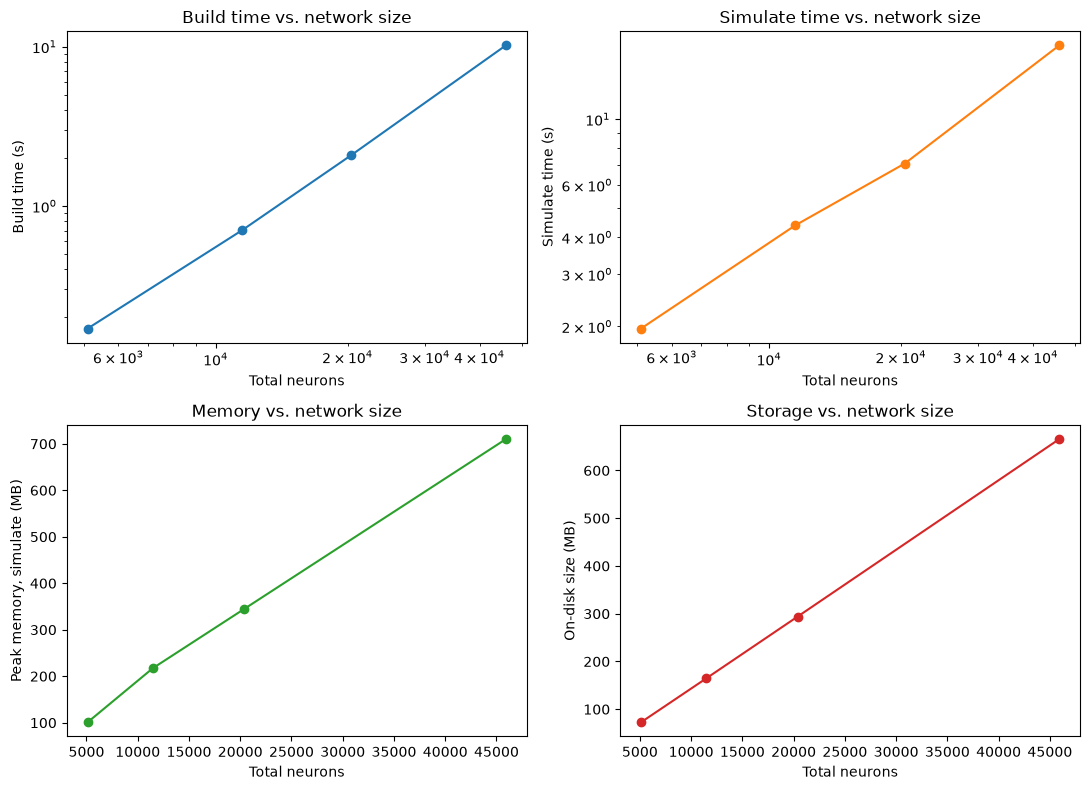

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df['n_total'], df['t_build_s'], marker='o')
axes[0, 0].set_xlabel('Total neurons'); axes[0, 0].set_ylabel('Build time (s)')
axes[0, 0].set_xscale('log'); axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Build time vs. network size')

axes[0, 1].plot(df['n_total'], df['t_sim_s'], marker='o', color='tab:orange')
axes[0, 1].set_xlabel('Total neurons'); axes[0, 1].set_ylabel('Simulate time (s)')
axes[0, 1].set_xscale('log'); axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Simulate time vs. network size')

axes[1, 0].plot(df['n_total'], df['peak_mem_sim_mb'], marker='o', color='tab:green')
axes[1, 0].set_xlabel('Total neurons'); axes[1, 0].set_ylabel('Peak memory, simulate (MB)')
axes[1, 0].set_title('Memory vs. network size')

axes[1, 1].plot(df['n_total'], df['disk_mb'], marker='o', color='tab:red')
axes[1, 1].set_xlabel('Total neurons'); axes[1, 1].set_ylabel('On-disk size (MB)')
axes[1, 1].set_title('Storage vs. network size')

plt.tight_layout()
plt.show()


## Reading the results

- If `t_build_s` grows noticeably faster than `n_total` (super-linear on the log-log plot),
  that's the connectivity search — evaluating every candidate pair within cutoff distance —
  outpacing the fixed `NUM_PE` processes available to share the work. This is expected here,
  and it's the paper's `Tbuild` scaling under the opposite condition (compute held fixed instead
  of growing with the network).
- `t_step_ms` (not plotted above, but in `df`) is the same normalized metric as the paper's
  Tables 2/3 — worth comparing its *shape* across sizes even though the absolute numbers won't
  match Summit.
- Once this runs cleanly, a natural next experiment is holding `rect_side` fixed and instead
  sweeping `NUM_PE` — that's the local equivalent of the paper's *strong* scaling test.